In [63]:
import numpy as np
from matplotlib import pyplot as plt

In [76]:
def gen_impulses(fs, dur, isi, height=1, jitter=0):
    n = int(dur*fs)
    isis = np.atleast_1d(isi)
    X = np.zeros((n, len(isis)))
    for i, isi in enumerate(isis):
        t_event = np.arange(isi, dur, isi)
        t_event += np.random.uniform(-jitter, jitter, t_event.size)
        idx = (t_event * fs).astype(int)
        h = height if not isinstance(height, list) else height[i]
        X[idx, i] = h
    t = np.linspace(0, dur, n)
    return X, t

def gen_trf(fs, dur, peak, width):
    peaks = np.atleast_1d(peak)
    trf = np.zeros((int(fs*dur), len(peaks)))
    t = np.linspace(0, dur, int(dur*fs))
    for i, peak in enumerate(peaks):
        w = width if not isinstance(width, list) else width[i]
        trf[:,i] = np.exp(-((t - peak) ** 2) / (2 * w** 2))
    return trf, t

def simulate_response(X, trf, noise_factor=1):
    y = np.zeros(len(X))
    for i in range(X.shape[1]):
        y += np.convolve(X[:, i], trf[:, i], mode="full")[:len(X)]
    y -= y.mean()
    y /= X.shape[1]
    y += np.random.randn(y.size)*noise_factor
    return y

def gen_lags(X, n_lags):
    n, k = X.shape
    X_lag = np.zeros((n, k * n_lags))
    for lag in range(n_lags):
        X_lag[lag:, lag*k:(lag+1)*k] = X[:n-lag]
    return X_lag

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def pearsonr(y_true, y_pred):
    return np.corrcoef(y_true, y_pred)[0, 1]

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

class utils:
    gen_trf = gen_trf
    gen_impulses = gen_impulses
    gen_lags = gen_lags
    simulate_response = simulate_response
    mse = mse
    pearsonr = pearsonr
    r_squared = r_squared

## Creating a Time-Lagged Design Matrix

Generate impulse stimulus at `100` Hz sampling rate.

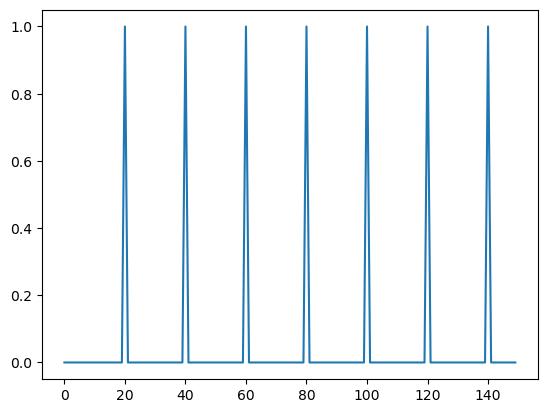

In [65]:
fs = 100
X, t = utils.gen_impulses(fs, dur=1.5, isi=0.2)
plt.plot(X);

**Example**: Generate and plot design matrix with 5 lags.

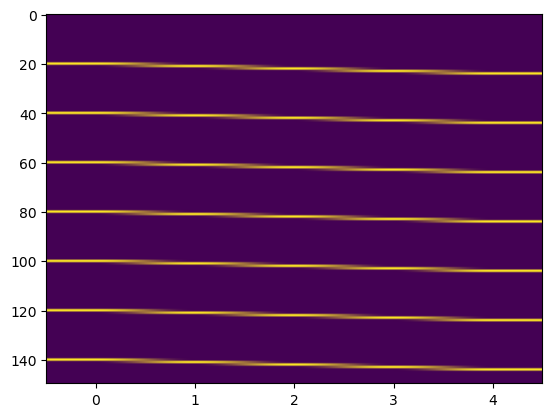

In [66]:
n_lag = 5
n, _ = X.shape
X_lag = np.zeros((n, n_lag))
for lag in range(n_lag):
    X_lag[lag:, lag:(lag+1)] = X[:n-lag]

plt.imshow(X_lag, aspect="auto", interpolation=None)

**Excercise**: Generate and plot design matrix with 20 lags.

Text(0.5, 0, 'Lags')

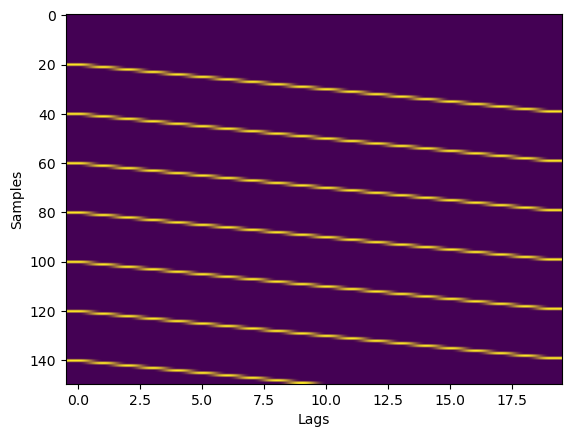

In [67]:
n_lag = 20
n, _ = X.shape
X_lag = np.zeros((n, n_lag))
for lag in range(n_lag):
    X_lag[lag:, lag:(lag+1)] = X[:n-lag]

plt.imshow(X_lag, aspect="auto", interpolation=None)
plt.ylabel("Samples")
plt.xlabel("Lags")

Generate two stimulus features of opposite sign and differnt ISI

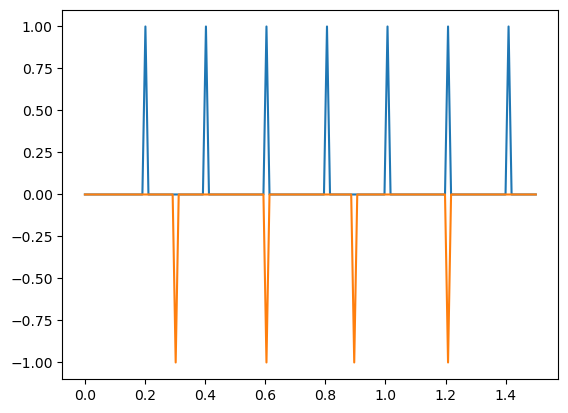

In [77]:
X, t = utils.gen_impulses(fs=100, dur=1.5, isi=[0.2, 0.3], height=[1, -1])
plt.plot(t, X);

**Exercise**: Create a design matrix with 10 lags.

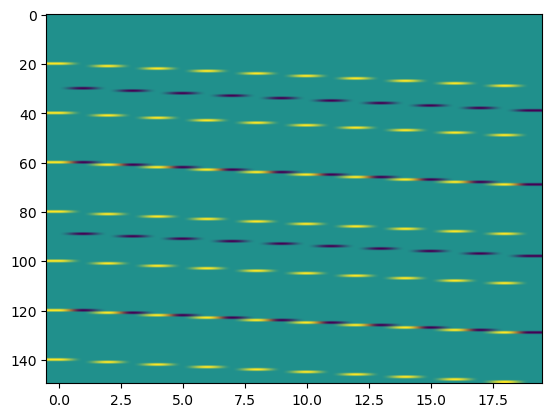

In [78]:
n_lag = 10
n, k = X.shape
X_lag = np.zeros((n, k * n_lag))
for lag in range(n_lag):
    X_lag[lag:, lag*k:(lag+1)*k] = X[:n-lag]

plt.imshow(X_lag, aspect="auto", interpolation=None)

**Exercise**: generate the same design matrix with the `utils.gen_lags()` function.

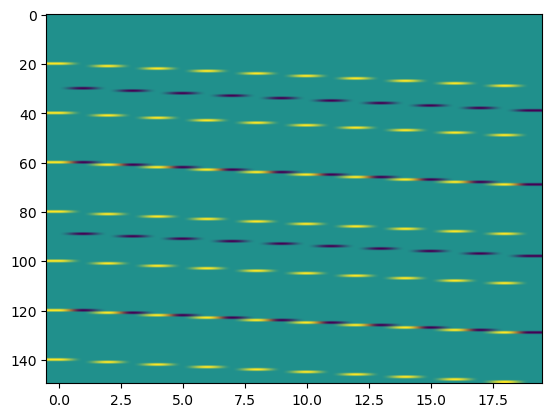

In [79]:
X_lag = utils.gen_lags(X, n_lags=10)
plt.imshow(X_lag, aspect="auto", interpolation=None)

## Time-Lagged Regression

Simulate neural response from impulses and TRF

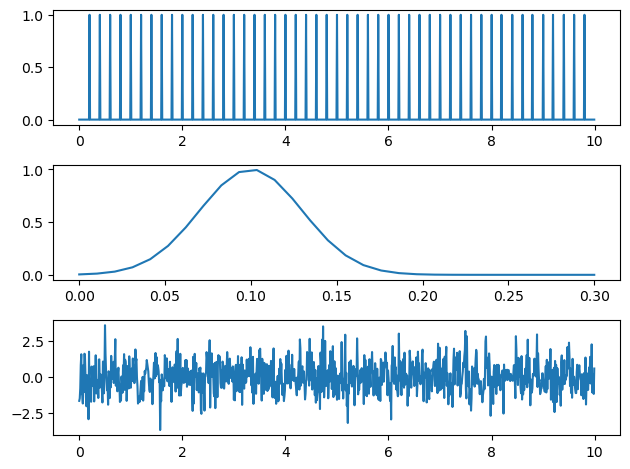

In [80]:
fs = 100

X, t = utils.gen_impulses(fs, dur=60, isi=0.2)
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=0.1, width=0.03)
y = utils.simulate_response(X, trf)

fig, ax = plt.subplots(3)
ax[0].plot(t[:1000], X[:1000])
ax[1].plot(t_trf, trf)
ax[2].plot(t[:1000], y[:1000])
plt.tight_layout()

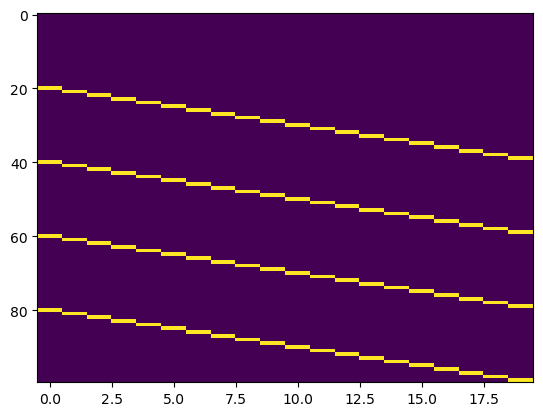

In [81]:
X_lag = utils.gen_lags(X, n_lags=20)
plt.imshow(X_lag[:100], aspect="auto")

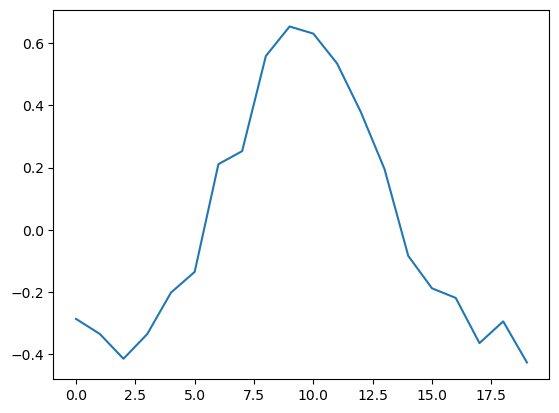

In [82]:
b = np.linalg.solve(X_lag.T @ X_lag, X_lag.T@y)
plt.plot(b)

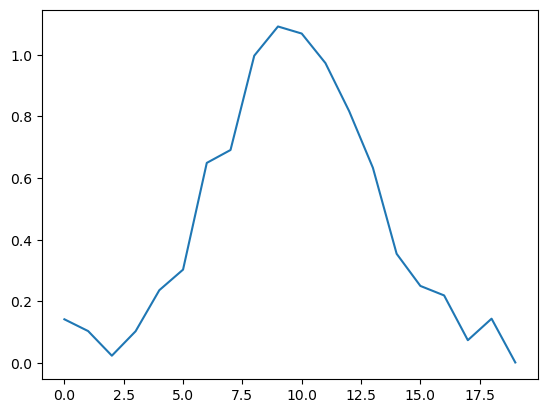

In [83]:
X_lag = utils.gen_lags(X, n_lags=20)
X_lag = np.c_[np.ones((len(X_lag), 1)), X_lag]
b = np.linalg.solve(X_lag.T @ X_lag, X_lag.T@y)
plt.plot(b[1:])

In [ ]:
plt.plot(t, b[1:])
plt.xlabel("Time lag [ms]")

In [ ]:
fs = 150

X, t = utils.gen_impulses(fs, dur=120, isi=[0.2, 0.5])
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=[0.06, 0.11], width=[0.02, 0.03])
y = simulate_response(X, trf, noise_factor=0.1)

fig, ax = plt.subplots(3)
ax[0].plot(X[:1000, :])
ax[1].plot(trf)
ax[2].plot(y)

In [ ]:
max_lag = 30
n, k = X.shape
X_lag = np.zeros((n, k * max_lag))
for lag in range(max_lag):
    X_lag[lag:, lag*k:(lag+1)*k] = X[:n-lag]

X_lag = np.c_[np.ones((n, 1)), X_lag]
b = np.linalg.solve(X_lag.T @ X_lag, X_lag.T@y)

b.shape

In [ ]:
plt.plot(b[1:].reshape(max_lag, k)
);

## Evaluating Model Accuracy

In [ ]:

fs = 150

X, t = utils.gen_impulses(fs, dur=120, isi=[0.2, 0.5])
trf, t_trf = utils.gen_trf(fs, dur=0.3, peak=[0.06, 0.11], width=[0.02, 0.03])
y = simulate_response(X, trf, noise_factor=0.1)

In [ ]:
max_lag = 20
n, k = X.shape
X_lag = np.zeros((n, k * max_lag))
for lag in range(max_lag):
    X_lag[lag:, lag*k:(lag+1)*k] = X[:n-lag]

In [ ]:
b = np.linalg.solve(X_lag.T @ X_lag, X_lag.T@y)
b.shape